In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
url='https://www.censtatd.gov.hk/api/get.php?id=310-31001&lang=en&full_series=1'

def read_json(url):
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
    r=requests.get(url, headers=headers)
    if r.ok:
        data=r.json()
    return data

data=read_json(url)
hk_gdp=pd.DataFrame(list(filter(lambda i: (i['freq']=='Y') & (int(i['period'][:4])>1980) & (i['svDesc']=='HK$ million') 
                         & (i['sv']=='CUR'), data['dataSet'])))
hk_gdp=hk_gdp.set_index('period')
hk_gdp['gdp']=hk_gdp['figure']
hk_gdp.head()

,freq,sv,svDesc,figure,sd_value,gdp
period,,,,,,
1981,Y,CUR,HK$ million,173578,,173578
1982,Y,CUR,HK$ million,196005,,196005
1983,Y,CUR,HK$ million,217281,,217281
1984,Y,CUR,HK$ million,261992,,261992
1985,Y,CUR,HK$ million,278128,,278128


In [3]:
url='https://api.hkma.gov.hk/public/market-data-and-statistics/monthly-statistical-bulletin/money/supply-adjusted?pagesize=1500'
data=read_json(url)
# hk_m2=pd.DataFrame(list(filter(lambda i: '-12' in i['end_of_month'], data['result']['records'])))[['end_of_month', 'm2_total']]
hk_m2=pd.DataFrame(data['result']['records'])
hk_m2['M2']=hk_m2['m2_total']
hk_m2=hk_m2.set_index('end_of_month')
hk_m2.index=pd.to_datetime(hk_m2.index)

In [4]:
url='https://api.hkma.gov.hk/public/market-data-and-statistics/monthly-statistical-bulletin/ef-fc-resv-assets/fc-resv-assests?pagesize=1500'
data=read_json(url)
hk_exfund=pd.DataFrame(data['result']['records'])
hk_exfund=hk_exfund.set_index('end_of_month')
hk_exfund.index=pd.to_datetime(hk_exfund.index)

<Axes: xlabel='end_of_month'>

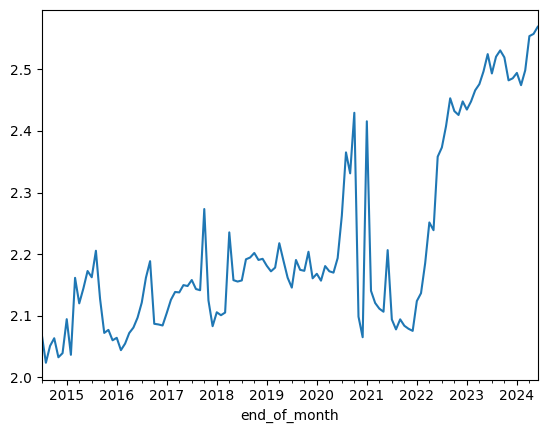

In [5]:
df_hk=pd.concat([hk_m2['m2_hkd'], hk_exfund['fc_resv_assets_ef']*7.8], axis=1)
(df_hk['m2_hkd']/df_hk['fc_resv_assets_ef'])[-120:].plot()

In [6]:
api_key='29de704f-b44b-494b-aa78-6d845add7dc0'
# headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36',
#            'keyid': api_key}
headers = {'keyid': api_key}
# url='https://eservices.mas.gov.sg/apimg-gw/server/monthly_statistical_bulletin/table_i_1a_money_supply_all_currencies/views/table_i_1a_money_supply_all_currencies?year=2024'
url='https://eservices.mas.gov.sg/apimg-gw/server/monthly_statistical_bulletin/table_i_1_money_supply_sgd/views/table_i_1_money_supply_sgd'
r=requests.get(url, headers=headers)
# r.json()
r

KeyboardInterrupt: 